# **Final Project - Code**

CCT416 Final Project - Social Data Analytics

Group 5: 
- Minyoung Suk (1009597474)
- Dhruva Bhatt (1008912893)
- Chih Yu Chiang (1009445138)
- Zaina Hibah (1007293153)


**Research Question:**
“Among university students, which behavioural and demographic characteristics (e.g., sleep hours, social media use, age, diet quality) are most associated with academic performance?” 

This project uses Exportratory Data Analysis (EDA), Correlation Analysis, feature importance analysis, and OLS Regression to identify the strongest predictors of academic performance based on a student habits/demographic dataset.

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import math
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler

# CATEGORICALS_ENCODED is set to True once the categorical variables in the data are encoded (see section 3) 
CATEGORICALS_ENCODED = False

We imported all data science libraries we are planning to use for data manipulation, visualization, and regression modelling.

## 2. Load DataSet

In [2]:
df = pd.read_csv('student_habits_performance.csv')

We load the dataset 'student_habits_performance.csv', which contains 1000 records on students' lifestyle habits, demographic, and academic performance.  

Below is a preview of the first few rows:

In [3]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [5]:
print(df.columns)

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')


## 3. Data Cleaning and Preprocessing

We check for missing values, convert categorical variables into numeric format, and prepare the dataset for regression model.

### 3.1 Data Cleaning - Missing (null) values

In [6]:
# Check missing values
missing_values = df.isnull().sum()
print("Missing Values Per Column:\n", missing_values)

Missing Values Per Column:
 student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64


There are **91 missing values** on **parental_education_level** column. However, after closer inspection of the values in the dataset, it becomes clear that the missing data is actually not missing data. The values that appear as 'None' for parental_education_level indicate the parent has had no education.  


This assumption can be made because  
(1) the data was generated artifically, made great for training, indicating that missing values are unlikely  
(2) the stats displayed in source site (kaggle) indicate that there are no empty entries for this variable. 

In [7]:
# Handle null values

# Fill missing values in parental_education_level to be "No Education"
df['parental_education_level'].fillna("No Education", inplace=True)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_27404\2128505126.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['parental_education_level'].fillna("No Education", inplace=True)


In [8]:
# Final data check: re-check missing values and data types
print('Missing Values Per Column:\n', df.isnull().sum())

df.info()

Missing Values Per Column:
 student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   o

### 3.2 Preprocessing - Encode Categorical Variables

In [9]:
# Encode Categorical Variables
# First, print out all the unique values entered under parental_education_level.
parental_education_level_values = df['parental_education_level'].unique()
print("\nCategorical Values Under parental_education_level: \n\n    ", parental_education_level_values)


Categorical Values Under parental_education_level: 

     ['Master' 'High School' 'Bachelor' 'No Education']


In [10]:
# Next, encode categorical variables if not already encoded.
if not CATEGORICALS_ENCODED:
    # Create the mappings for categorical valued and boolean valued variables.
    gender_mapping = {'Male': 0, 'Female': 1, 'Other': 3}
    part_time_job_mapping = {'Yes': 1, 'No': 0}
    diet_quality_mapping = {'Fair': 2, 'Good': 3, 'Poor': 1}
    parental_education_mapping = {'Master': 3, 'High School': 2, 'Bachelor': 1, 'No Education': 0}
    internet_quality_mapping = {'Average': 2, 'Good': 3, 'Poor': 1}
    extracurricular_participation_mapping = {'Yes': 1, 'No': 0}

    # Apply the mapping to each respective categprical variable. 
    df['gender'] = df['gender'].map(gender_mapping)
    df['part_time_job'] = df['part_time_job'].map(part_time_job_mapping)
    df['diet_quality'] = df['diet_quality'].map(diet_quality_mapping)
    df['parental_education_level'] = df['parental_education_level'].map(parental_education_mapping)
    df['internet_quality'] = df['internet_quality'].map(internet_quality_mapping)
    df['extracurricular_participation'] = df['extracurricular_participation'].map(extracurricular_participation_mapping)

    CATEGORICALS_ENCODED = True

# Preview first 5 rows of datasent to verify encoding of categorical values. 
df.head()
df.isnull().sum()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

## 4. New Features (Created)

Since we are studying the correlation between behavioural and demographic charastics and academic productivity, we need to ways to measure productivity in terms of both habits (such as exercise, sleep hours, and studying) in order to make a more accurate analysis on the variability through both exploratory analysis and OLS regression. For this reason, we will create features that reflect the (1) the ROI (return on investment) from the positive habits have and (2) the level of bad habits (in the case offered by this dataset, those habits would be there level screen time). 

| **Feature** | **Data type** | **Expected Value** | **Description** |
|-----------------|---------------|-------------|-----------|
| **study_roi** | Float | Value from 0-1 (exclusive) | How efficiently students use their time when studying |
| **productivity_score** | Float | 0-100% | How much students are productive - including studying and staying healthy |
| **productivity_roi** | Float | Value from 0-1 (exclusive) | Return on Investment, i.e. hoe effective student's productivity score was on there exam |
| **problematic_screen_use_score** | Float | Value from 0-1 (exclusive) | Screen time addiction as a binary variable based on hours spent on screen|
| **screen_time_addiction** | Categorical | 'Low\n(1-3 hours/day)' / 'Medium\n(3-5.5 hours/day)' / 'High\n(5.5-7.5 hours/day)' / 'Very High\n(7.5+ hours/day)' | Level of screen time addiction student suffers from |

### **4.1 Study ROI**

In [11]:
# Study ROI (How efficiently students use their time when studying)
# Create a new column for study_roi
# This will be calculated as exam score divided by study hours per day

# Define study_roi as exam score divided by study hours per day
df['study_roi'] = df['exam_score'] / df['study_hours_per_day'].replace(0, 0.0001)

# Calculate the average study_roi
average_study_roi = df['study_roi'].mean()
print("Average Study ROI (Exam Score per Study Hour):", average_study_roi)
print('Average Exam Score:', df['exam_score'].mean())
print('Average Study Hours per Day:', df['study_hours_per_day'].mean())

Average Study ROI (Exam Score per Study Hour): 5327.431045138574
Average Exam Score: 69.6015
Average Study Hours per Day: 3.5501000000000005


### **4.2 Productivity Score**

In [12]:
# Productivity Score (How much students are productive - including studying and staying healthy)
# Create a new column for productivity_score
# This will be calculated as exam score divided by 

# Normalize study_hours_per_day to fit the scale 1-100
scaler = MinMaxScaler(feature_range=(0, 100))
normalized_study_hours_per_day = scaler.fit_transform(df[['study_hours_per_day']])

# Normalize sleep_hours to fit the scale 1-100
scaler = MinMaxScaler(feature_range=(0, 100))
normalized_sleep_hours = scaler.fit_transform(df[['sleep_hours']])

# Normalize exercise_frequency to fit the scale 1-100
scaler = MinMaxScaler(feature_range=(0, 100))
normalized_exercise_frequency = scaler.fit_transform(df[['exercise_frequency']])

# Normalize diet_quality to fit the scale 1-100
scaler = MinMaxScaler(feature_range=(0, 100))
normalized_diet_quality = scaler.fit_transform(df[['diet_quality']])

# Calculate and save productivity_score score as new colums in the dataframe. 
df['productivity_score'] = (normalized_diet_quality.flatten() + normalized_study_hours_per_day.flatten() + normalized_sleep_hours.flatten() + normalized_exercise_frequency.flatten()) / 4

# Preview first 10 rows in dataframe to view new feature. 
print(df[['productivity_score']].head())

   productivity_score
0           55.147059
1           75.930191
2           26.030593
3           41.737538
4           46.310241


### **4.3 Productivity ROI**

In [13]:
# Productivity ROI (Return on investment from students productivity)
# Create a new column for productivity_roi
# This will be calculated as exam score divided by productivity score

# Calculate and save productivity score as new colums in the dataframe. 
df['productivity_roi'] = (df['exam_score'] / df['productivity_score']).replace(0, 0.0001)

# Calculate the average productivity ROI
average_productivity_roi = df['productivity_roi'].mean()
print("Average Productivity ROI (Exam Score per Study Hour):", average_productivity_roi)
print('Average Exam Score:', df['exam_score'].mean())
print('Average Productivity Score:', df['productivity_score'].mean())

Average Productivity ROI (Exam Score per Study Hour): 1.47381067250944
Average Exam Score: 69.6015
Average Productivity Score: 50.30299875974487


### **4.4 Screen Time Addiction**

In [14]:
# Screen Time Addiction (New Column, feature)
# Define screen time addiction as a binary variable based on hours spent on screen

# Define screen time addiction variables
def Problematic_Screen_Use_Score(netflix_hours, social_media_hours):
    """
    Measures screen time and the measure problematic usage (addiction) based on Netflix and social media hours.

    Parameters:
    netflix_hours (float): Daily hours spent on Netflix.
    social_media_hours (float): Daily hours spent on social media.

    Returns:
    float: A score representing problematic screen use. From 0 to 1, 0 (no addiction) to 1 indicates high addiction.
    """

# Thresholds
    netflix_threshold = 2  # hours/day
    social_media_threshold = 3  # hours/day
    total_threshold = 5  # total hours/day
    gamma = 1.2 # sensitivity of addiction curve

# Total screen time
    total_screen_time = netflix_hours + social_media_hours

# Penalty if above individual thresholds
    netflix_penalty = 1 + 0.25 * max(0, netflix_hours - netflix_threshold)
    social_media_penalty = 1 + 0.25 * max(0, social_media_hours - social_media_threshold)

# Combined panalty
    combined_penalty = netflix_penalty * social_media_penalty

# Base addiction score using a logistic function
    base_score = 1 / (1 + math.exp(-gamma * (total_screen_time - total_threshold)))

# Final addiction score with penalties applied, capped at 1
    addiction_score = min(1, base_score * combined_penalty, 1.0)

    return round(addiction_score, 3)

# Add the new problematic screen use score column to the DataFrame
df['problematic_screen_use_score'] = df.apply(lambda row: Problematic_Screen_Use_Score(row['netflix_hours'], row['social_media_hours']), axis=1)

# Print the first 5 rows of the new problematic screen use score column
print(df[['problematic_screen_use_score']].head())

   problematic_screen_use_score
0                         0.038
1                         0.570
2                         0.336
3                         0.576
4                         0.635


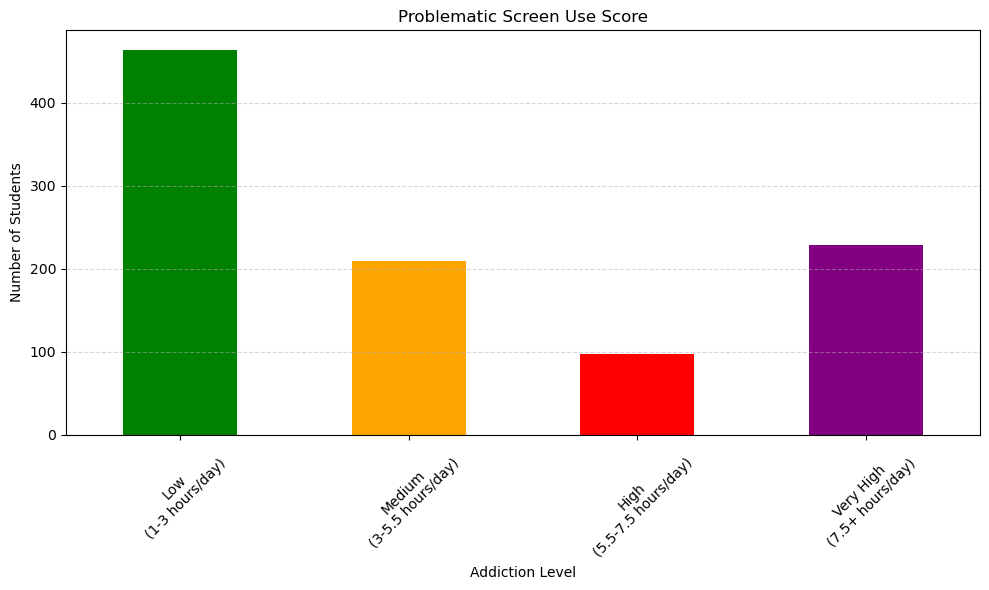

In [15]:
# Calculate the problematic screen use score for each student
df['problematic_screen_use_score'] = df.apply(
    lambda row: Problematic_Screen_Use_Score(row['netflix_hours'], row['social_media_hours']),
    axis=1
)

# Categorize problematic screen use score into low, medium, and high addiction groups
def categorize_addiction(score):
    if score < 0.3:
        return 'Low\n(1-3 hours/day)'
    elif score < 0.6:
        return 'Medium\n(3-5.5 hours/day)'
    elif score < 0.8:
        return 'High\n(5.5-7.5 hours/day)'
    else:
        return 'Very High\n(7.5+ hours/day)'

df['screen_time_addiction'] = df['problematic_screen_use_score'].apply(categorize_addiction)

# category ordering
category_order = [
    'Low\n(1-3 hours/day)', 
    'Medium\n(3-5.5 hours/day)', 
    'High\n(5.5-7.5 hours/day)',  # Make sure the catergory order is low to very high
    'Very High\n(7.5+ hours/day)' # This is the order of categories in the bar chart
]

# Count each category
category_counts = df['screen_time_addiction'].value_counts().reindex(category_order, fill_value=0) # Use reindex to include catergory ordering

# Plot bar chart
plt.figure(figsize=(10, 6))
category_counts.plot(kind='bar', color=['green', 'orange', 'red', 'purple'])

plt.title('Problematic Screen Use Score')
plt.xlabel('Addiction Level')
plt.ylabel('Number of Students')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

0.0 to 0.3: Low or healthy usage  
0.3 to 0.6: Moderate risk  
0.6 to 0.8: High risk  
0.8 to 1.0: Very high, addicted  

## 5. Exporing Data - Exploratory Data Analysis (EDA)

We explore the distribution and relationships between variables. Below is a correlation heatmap showing the strength of linear relationships with 'exam_score'.

### 5.1 Descriptive Statistics

In [16]:
# Data's central tendency (mean, median), dispersion (standard deviation), and shape.
print(df.describe())

             age       gender  study_hours_per_day  social_media_hours  \
count  1000.0000  1000.000000           1000.00000         1000.000000   
mean     20.4980     0.607000              3.55010            2.505500   
std       2.3081     0.700744              1.46889            1.172422   
min      17.0000     0.000000              0.00000            0.000000   
25%      18.7500     0.000000              2.60000            1.700000   
50%      20.0000     1.000000              3.50000            2.500000   
75%      23.0000     1.000000              4.50000            3.300000   
max      24.0000     3.000000              8.30000            7.200000   

       netflix_hours  part_time_job  attendance_percentage  sleep_hours  \
count    1000.000000    1000.000000            1000.000000  1000.000000   
mean        1.819700       0.215000              84.131700     6.470100   
std         1.075118       0.411028               9.399246     1.226377   
min         0.000000       0.0000

### 5.2 Uncovering Patterns

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_27404\776925543.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='study_hour_group', y='exam_score', data=df, palette="Set2")


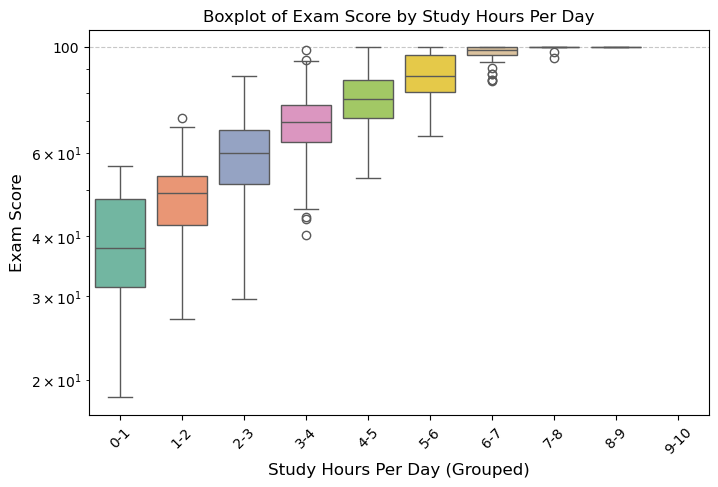

In [17]:
# Boxplot: Exam score by study hours

# Create study hour bins for visualization
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins) - 1)]
df['study_hour_group'] = pd.cut(df['study_hours_per_day'], bins=bins, labels=labels, right=False)

plt.figure(figsize=(8,5))
sns.boxplot(x='study_hour_group', y='exam_score', data=df, palette="Set2")
plt.xlabel("Study Hours Per Day (Grouped)", fontsize=12)
plt.ylabel("Exam Score", fontsize=12)
plt.xticks(rotation=45)
plt.title("Boxplot of Exam Score by Study Hours Per Day")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout

plt.yscale("log") # Log scale for better spread
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter()) # Show plain numbers

plt.show()

This box plot shows exam scores by study hour range. Students are binned into 1 hour groups.

**Key observations:**
- There’s an upward trend: students who study more hours get higher scores.
- Median score increases across higher study hour groups.
- There’s **less variability** in scores for students who study more — more consistent study habits mean more predictable grades.

This plot confirms the positive relationship between study time and productivity, as we found in our regression and correlation analysis.

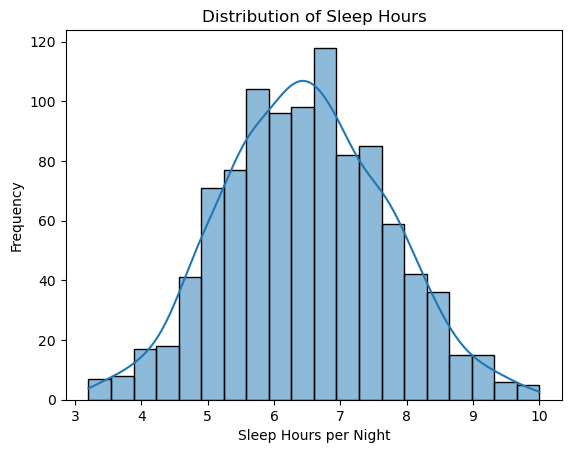

In [18]:
# Histogram: sleep hours

sns.histplot(data=df, x="sleep_hours", kde=True)
plt.title("Distribution of Sleep Hours")
plt.xlabel("Sleep Hours per Night")
plt.ylabel("Frequency")
plt.show()

The histogram above shows the distribution of `sleep_hours` in the dataset.

Key observations:
- Most students sleep between **6 to 8 hours** per night, which is the general health recommendation for adults.
- A few students sleep less than 5 hours or more than 9 hours, which could be irregular sleep patterns or lifestyle imbalances.
- The distribution is slightly **right skewed**, with a few students sleeping more than average.

This visualization suggests we should explore whether students with **longer or more consistent sleep** do better academically.

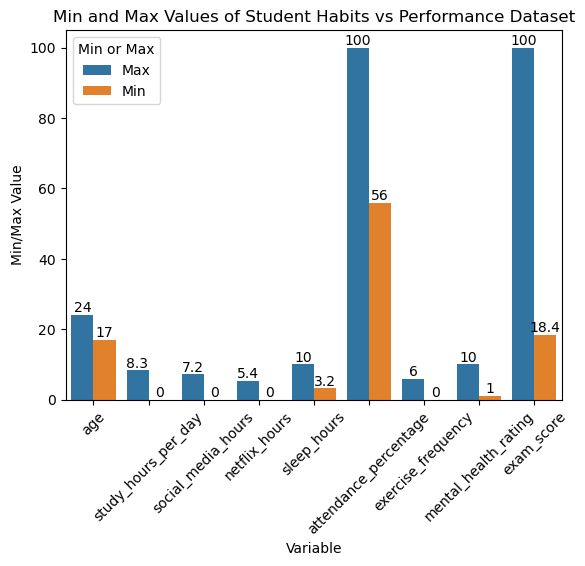

In [19]:
# Find max & min values

# Create data frame with min and max values of selected variables. 
minMaxDf = pd.DataFrame(columns=['Variable', 'Min/Max Value', 'Min or Max'])

# Add entry for each variable. 
for col in ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'sleep_hours', 'attendance_percentage', 'exercise_frequency', 'mental_health_rating', 'exam_score']:
    maxData = df[col].max()
    minData = df[col].min()
    maxEntry = pd.DataFrame({'Variable': [col], 'Min/Max Value': [maxData], 'Min or Max': ['Max']})
    minEntry = pd.DataFrame({'Variable': [col], 'Min/Max Value': [minData], 'Min or Max': ['Min']})
    minMaxDf = pd.concat([minMaxDf, maxEntry, minEntry], ignore_index=True)

# Plot bar graph to show min and max variables. 
barplt = sns.barplot(data=minMaxDf, x="Variable", y="Min/Max Value", hue="Min or Max")
plt.xticks(rotation=45)
plt.title("Min and Max Values of Student Habits vs Performance Dataset")

for container in barplt.containers:
    barplt.bar_label(container)
plt.show()


### 5.3 Correlation Analysis  

- Identify relationships
- Feature selection
- Avoid Misinterpretation

In [20]:
# Calculating correlation between numerical features
correlation_matrix = df.drop(columns=['student_id', 'screen_time_addiction', 'study_hour_group']).corr()

# Display the correlation matrix
print("Correlation Matrix:\n", correlation_matrix)

Correlation Matrix:
                                     age    gender  study_hours_per_day  \
age                            1.000000 -0.009461             0.003971   
gender                        -0.009461  1.000000             0.023329   
study_hours_per_day            0.003971  0.023329             1.000000   
social_media_hours            -0.009151  0.012503             0.020282   
netflix_hours                 -0.001174  0.025832            -0.031158   
part_time_job                 -0.011680 -0.015657            -0.029133   
attendance_percentage         -0.026055  0.016514             0.026264   
sleep_hours                    0.037482  0.050027            -0.027757   
diet_quality                   0.004117 -0.035741             0.033377   
exercise_frequency            -0.003836 -0.053949            -0.028701   
parental_education_level      -0.040719 -0.018897            -0.000011   
internet_quality               0.007799  0.058969             0.014459   
mental_health_rat

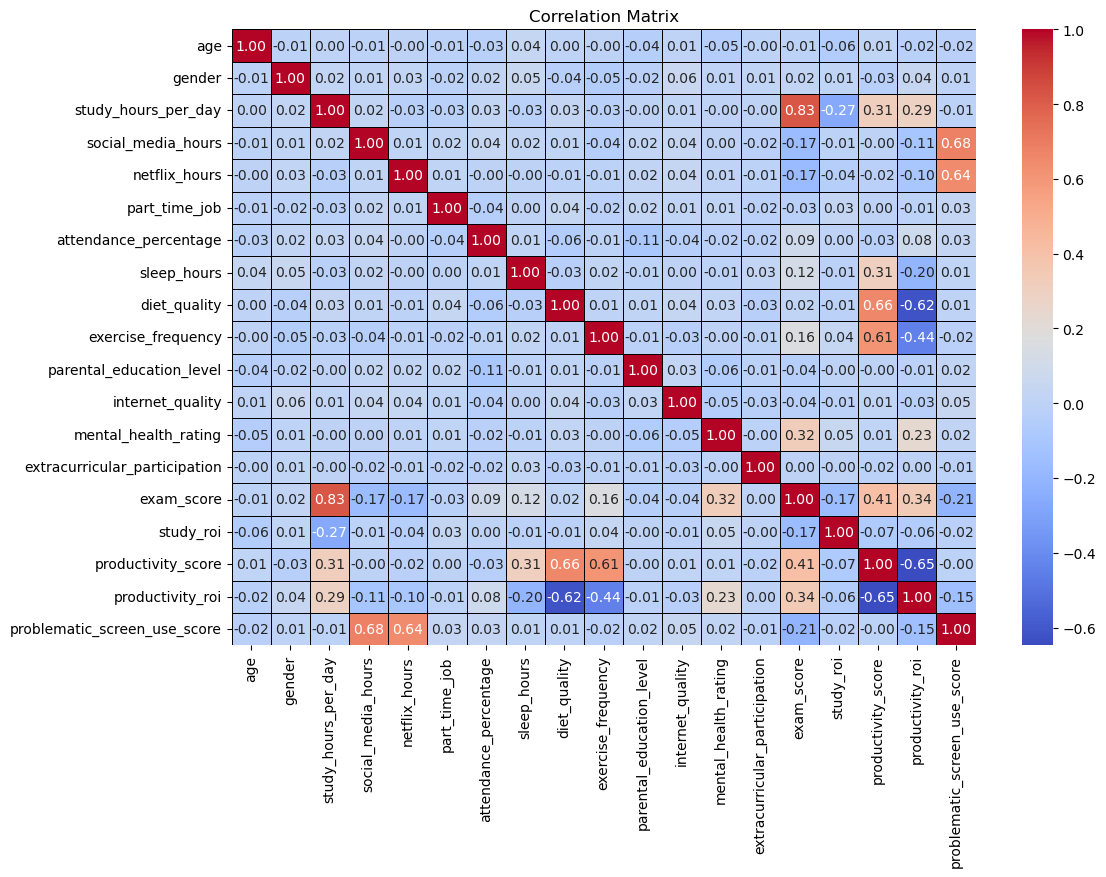

In [21]:
# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, linecolor='black')
plt.title('Correlation Matrix')
plt.show()

Study hours per day has most strong positive correlation

Social media use and netflix hours has negative correlation

In [22]:
# Calculating correlation between study hours per day and exam scores
studyHours_examScores_corr = df['study_hours_per_day'].corr(df['exam_score'])
print("Correlation between Study Hours Per Day and Exam Scores:", studyHours_examScores_corr)

Correlation between Study Hours Per Day and Exam Scores: 0.825418509396044


### 5.4 Analysis Results

Printing out the min and max values of each variables gives us insight into  
(1) the demographic of the students that are being analyzed in this dataset and  
(2) social implications within this demographic.   
In particular we can make the following assumptions and observations:
 - More study hours per day result in high academic achievement (exam score) 
 - Sleep hours per night are mostly distributed around 6.5 hours per night
 - The deomgraphic of students in this dataset is 17-24 year olds
 - No student got a zero on the exam (the min exam score being 18.4%), and at least one studetn studied no hours- so even student who never studies did not get a zero on their exam. 
 - There are students who do not watch Netflix and students who do not use social media daily. 
 - No students attended less than ~half (56 %) of classes in their term/school year. 

## 6. Methodology

### 6.1 Simple Linear Regression

**OLS Regression Model**

We use Ordinary Least Squares (OLS) regression to identify which variables significantly influence academic performance ('exam_score').

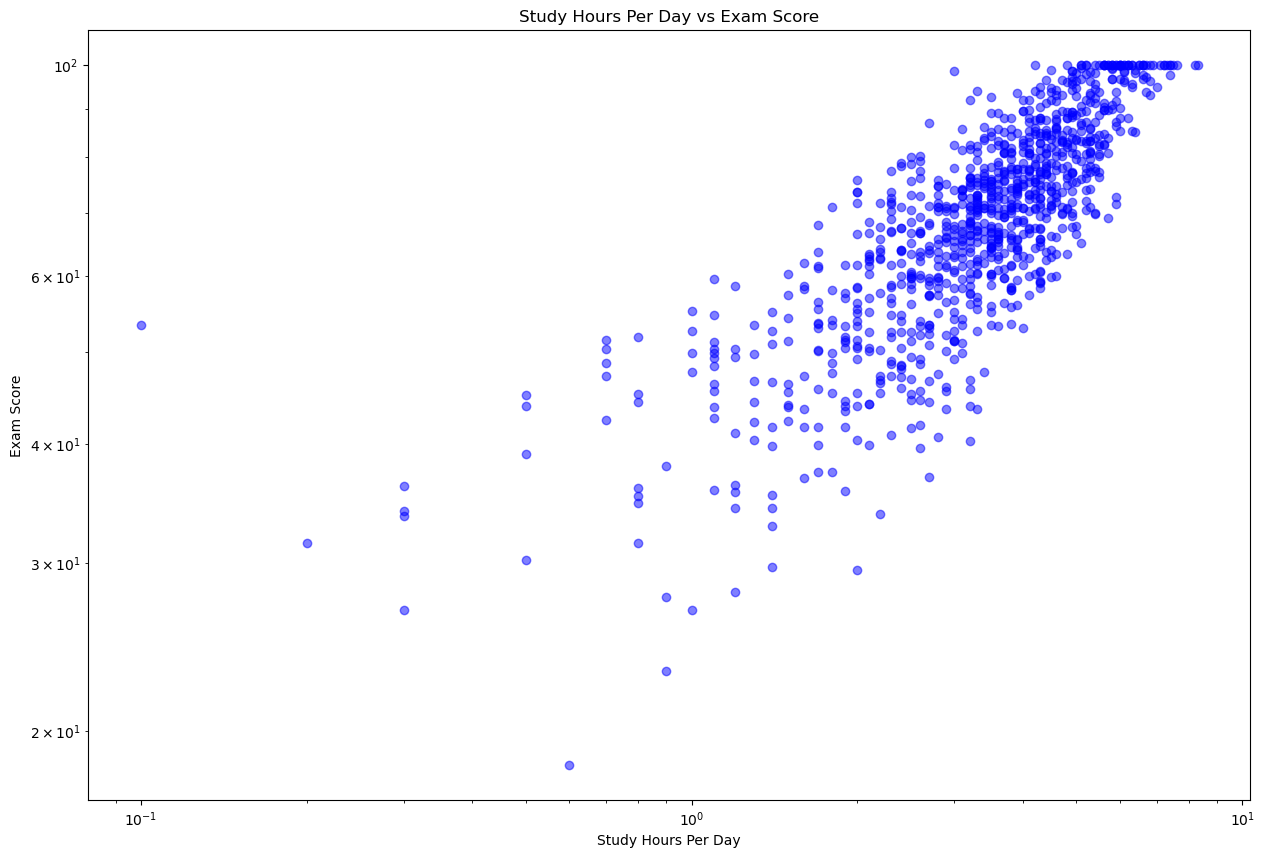

In [23]:
# Scatter plot of study hours per day vs exam scores
plt.figure(figsize=(15, 10))
plt.scatter(df['study_hours_per_day'], df['exam_score'], alpha=0.5, color='blue')
plt.xlabel('Study Hours Per Day')
plt.ylabel('Exam Score')
plt.title('Study Hours Per Day vs Exam Score')
plt.xscale("log")
plt.yscale("log")
plt.savefig("scatter_study_hours_exam_scores.png", dpi=300, bbox_inches='tight')
plt.show()

Regression Coefficient (Slope): 9.49025040589683
Intercept: 35.91016203402566


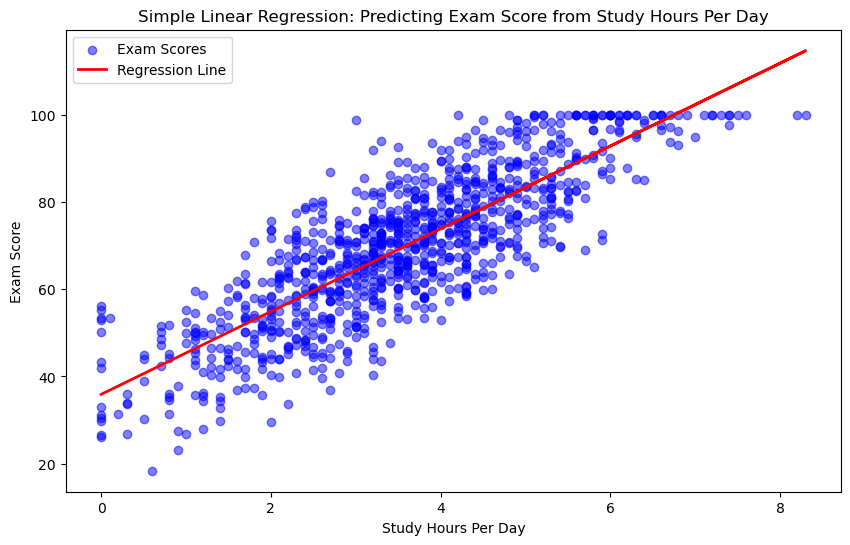

In [24]:
# Preparing data for simple linear regression
X = df['study_hours_per_day'].values.reshape(-1, 1)
y = df['exam_score'].values

# Creating and training the model
model = LinearRegression()
model.fit(X, y)

# Making predictions
df['predicted_exam_score'] = model.predict(X)

# Displaying the regression coefficient and intercept
print(f"Regression Coefficient (Slope): {model.coef_[0]}")
print(f"Intercept: {model.intercept_}")

# Plotting the regression line
plt.figure(figsize=(10, 6))
plt.scatter(df['study_hours_per_day'], df['exam_score'], alpha=0.5, color='blue', label='Exam Scores')
plt.plot(df['study_hours_per_day'], df['predicted_exam_score'], color='red', linewidth=2, label='Regression Line')
plt.xlabel('Study Hours Per Day')
plt.ylabel('Exam Score')
plt.title('Simple Linear Regression: Predicting Exam Score from Study Hours Per Day')
plt.legend()
plt.savefig("regression_study_hours_exam_scores.png", dpi=300, bbox_inches='tight')
plt.show()

In [25]:
# Define dependent and independent variables
X1 = df[['study_hours_per_day']]
y = df['exam_score']

# Add constant
X = sm.add_constant(X1)

# OLS regression
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.681
Method:                 Least Squares   F-statistic:                     2134.
Date:                Thu, 12 Jun 2025   Prob (F-statistic):          4.60e-250
Time:                        04:44:19   Log-Likelihood:                -3673.3
No. Observations:                1000   AIC:                             7351.
Df Residuals:                     998   BIC:                             7360.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  35.9102    

``
**68.1% of the variability in students'exam scores can be explained by their study hours alone**
``

This indicate that 'Study_Hours_Per_Day' is a strong predictor and study hour fits for prediction model. 

### 6.2 Multiple Linear Regression

In [26]:
# Define dependent and independent variables
X = df.drop(columns=['student_id', 'exam_score', 'screen_time_addiction', 'study_hour_group'])
y = df['exam_score']
# Add constant
X = sm.add_constant(X)

# OLS regression
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                     772.6
Date:                Thu, 12 Jun 2025   Prob (F-statistic):               0.00
Time:                        04:44:19   Log-Likelihood:                -2912.3
No. Observations:                1000   AIC:                             5861.
Df Residuals:                     982   BIC:                             5949.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

``
**P-values**
``

Significant predictors that have P-value smaller than 0.05 are
- Study hours per day
- Social media hours
- Netflix hours
- Attendance percentage
- Diet Quality
- Exercise frequency
- Mental health rating
- Study ROI
- Productivity Score
- Productivity ROI

The rest of the variables are not significant with P values higher than 0.05
- Age: 0.903
- Gender: 0.909
- Part-time job: 0.975
- Sleep hours: 0.972
- Parental education level: 0.490
- Internet quality: 0.307
- Extracurricular participation: 0.630
- Problematic_screen_use_score: 0.630

``
**F-statistic**
``

F-statistic is global test for regression model and test to reject the null.

$$
F-statistic = 772.6
$$

This model has statistically significant explanatory power.

``
**R-squared**
``

This Regression model already shows very significant accuracy and predictive power with R-squared of
$$
R^2 = 0.930
$$

``
**Adjusted R-squared**
``

$$
Adj. R^2 = 0.929
$$

No redundant predictors are included in the model as Adjusted R-squared is nearly the same as R-squared.

### 6.3 Random Forest Feature Importance

To validate our regression findings, we run a Random Forest model and extract feature importances.  
This allows us to see which features contribute most to predicting academic performance, even with non-linear effects.

In [27]:
model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X.drop(columns=['const']), y)

importances = model_rf.feature_importances_
importance_df = pd.DataFrame({'Feature': X.columns[1:], 'Importance': importances}).sort_values(by='Importance', ascending=False)

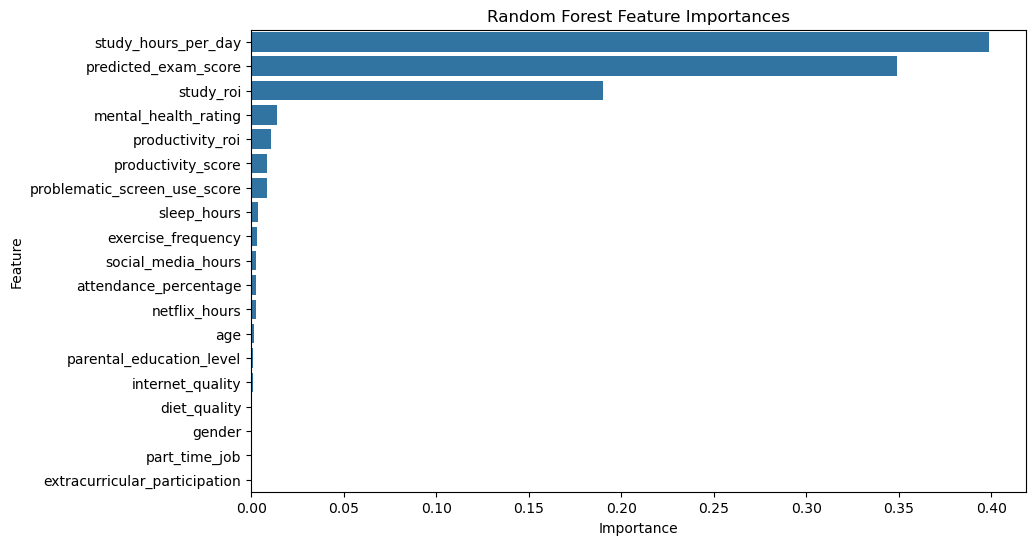

In [28]:
# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Random Forest Feature Importances')
plt.show()

### 6.4 Choosing the Final Multiple Linear Regression Model

In [29]:
# Iterate through each combination of features for the optimal Regression model based on greatest R-squared and f-statistic value. 
from itertools import combinations

features = [
    "study_hours_per_day",
    "social_media_hours",
    "netflix_hours",
    "attendance_percentage",
    "diet_quality",
    "exercise_frequency",
    "mental_health_rating",
    "study_roi",
    "productivity_score",
    "productivity_roi"
]

count = 0

for k in range(2, len(features) + 1):
    for combination in combinations(features, k):
        # Define dependent and independent variables
        X = df[list(combination)]
        y = df['exam_score']

        # Add constant
        X = sm.add_constant(X)

        # OLS regression
        model = sm.OLS(y, X).fit()

        # After playing around with the conditions, the most optimal model is narrowed from the large list of models. 
        if model.rsquared_adj > 0.85 and model.fvalue > 1700:
            print(combination)
            print("Adj. R-squared: ", model.rsquared_adj, "  |  F-statistic: ", model.fvalue)
            print("\n=======================================\n")
            count+=1

print(count)


('study_hours_per_day', 'productivity_score', 'productivity_roi')
Adj. R-squared:  0.8648405048052066   |  F-statistic:  2131.7558724237356


('study_hours_per_day', 'social_media_hours', 'productivity_score', 'productivity_roi')
Adj. R-squared:  0.8735811842887502   |  F-statistic:  1726.8261719082075


('study_hours_per_day', 'mental_health_rating', 'productivity_score', 'productivity_roi')
Adj. R-squared:  0.89064872866299   |  F-statistic:  2035.1740636745308


('study_hours_per_day', 'social_media_hours', 'mental_health_rating', 'productivity_score', 'productivity_roi')
Adj. R-squared:  0.9035756944895197   |  F-statistic:  1873.291667575287


('study_hours_per_day', 'netflix_hours', 'mental_health_rating', 'productivity_score', 'productivity_roi')
Adj. R-squared:  0.8986459947154484   |  F-statistic:  1772.5083803551802


('study_hours_per_day', 'diet_quality', 'mental_health_rating', 'productivity_score', 'productivity_roi')
Adj. R-squared:  0.8996354491961361   |  F-statistic: 

#### **Models with the Highest Adjusted R-value and F-statistic**

| Model Number | Features                                                                                                               | Adjusted R-squared | F-statistic        |
|---|------------------------------------------------------------------------------------------------------------------------|--------------------|--------------------|
| 1 | study_hours_per_day, productivity_score, productivity_roi                                                             | 0.8648             | 2131.76            |
| 2 | study_hours_per_day, social_media_hours, productivity_score, productivity_roi                                         | 0.8736             | 1726.83            |
| 3 | study_hours_per_day, mental_health_rating, productivity_score, productivity_roi                                       | 0.8906             | 2035.17            |
| 4 | study_hours_per_day, social_media_hours, mental_health_rating, productivity_score, productivity_roi                   | 0.9036             | 1873.29            |
| 5 | study_hours_per_day, netflix_hours, mental_health_rating, productivity_score, productivity_roi                        | 0.8986             | 1772.51            |
| 6 | study_hours_per_day, diet_quality, mental_health_rating, productivity_score, productivity_roi                         | 0.8996             | 1791.94            |
| 7 | study_hours_per_day, social_media_hours, netflix_hours, mental_health_rating, productivity_score, productivity_roi    | 0.9125             | 1737.92            |
| 8 | study_hours_per_day, social_media_hours, diet_quality, mental_health_rating, productivity_score, productivity_roi     | 0.9138             | 1765.89            |
| 9 | study_hours_per_day, social_media_hours, netflix_hours, diet_quality, mental_health_rating, productivity_score, productivity_roi | 0.9242             | 1739.90            |


#### Model Picking

Based on these models, it seems the optimal model is \#9, because although there are indeed models with significantly higher f-statistics (like model #3) they have lower R-squared indicating that not as much of the variability is explained in those models. Model #9 has the highest R-squared, indicating that most of the variablilty can be explained by the combination of study_hours_per_day, social_media_hours, netflix_hours, diet_quality, mental_health_rating, productivity_score, and productivity_roi. Additionally, the f-statisitc is significantly higher than the initial multiple regression model with all the features- with a large difference of ~1000. 

### 6.4 Final OLS Multiple Regression Model

In [30]:
# Conducting final Multiple linear regression with optimal F-statisitic and Adjusted R-squared that best explains the behavior of exam_score. 
# Define dependent and independent variables
X = df[['study_hours_per_day', 'social_media_hours', 'netflix_hours', 'diet_quality', 'mental_health_rating', 'productivity_score', 'productivity_roi']]
y = df['exam_score']

# Add constant
X = sm.add_constant(X)

# OLS regression
model = sm.OLS(y, X).fit()
print(combination)
print(model.summary())

('study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'diet_quality', 'exercise_frequency', 'mental_health_rating', 'study_roi', 'productivity_score', 'productivity_roi')
                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.925
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     1740.
Date:                Thu, 12 Jun 2025   Prob (F-statistic):               0.00
Time:                        04:44:31   Log-Likelihood:                -2952.0
No. Observations:                1000   AIC:                             5920.
Df Residuals:                     992   BIC:                             5959.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
     

``
**F-statistic**
``

$$
F-statistic = 1740
$$
F-statistic significantly improved by almost 1000  
  
  
``
**Adjusted R-squared**
``

$$
Adj. R^2 = 0.924
$$
Adjusted R-squared slightly got decrease by 0.005  

  
``
**Why we choose this model**
``

We chose our final OLS regression model based on a combination of statistical power and theoretical interpretability. Although this model has a slightly lower **adjusted R-squared (0.924)** compared to a previous one (0.929), it has a much higher **F-statistic (1740)**, indicating stronger overall model significance.

The F-statistic tests whether our full set of predictors jointly explain a significant portion of the variance in academic performance. A much higher F-value means that, overall, the variables in our final model are statistically strong and not random.


We chose the final model because:
- It has a **high adjusted R-squared**, still explaining over 92% of the variance in scores.
- It passes the **global significance test** with a very high F-statistic.
- All included variables have **theoretical meaning** and **practical interpretation**.

In short, the final model has a good balance of power and robustness and is clear to interpret — for real world application.

### Key Insights:
After conducting exploratory data analysis and OLS regression, we identified several important behavioral and demographic factors that influence academic productivity among university students.

- **Study Hours per Day** is the most influential predictor of academic performance. Students who dedicate more time to studying consistently score higher on exams, as confirmed by both correlation and regression results.

- **Mental health rating**,  and **Exercise Frequency** shows a positive relationship with exam scores. Students who exercise and has higher mental health rating perform better than those with significantly low mental health rating or irregular exercise schedules.

- **Attendance Percentage** somehow correlates with higher exam scores. Regular class attendance appears to be a reliable proxy for student engagement and academic success.

- **Diet Quality** were not statistically significant predictors in our final regression model, but may still play indirect roles through mental health and energy levels.

- New features such as **Study ROI**, **Productivity Score**, **Productivity ROI** has significant statistical value and are good predictors, as it has p-value < 0.05 and strongly correlated with exam score.

These insights suggest that academic productivity is most strongly tied to consistent behavioral routines like studying, sleeping well, eating well, and attending classes, rather than demographic or lifestyle factors alone.

## 7. Results

After generating multiple regression models for all feature combinations, we found the most optimal model that is the best at explaining the variability of student academic performance. The models has the following statistics:

---------------------

Predictors: features study_hours_per_day, social_media_hours, netflix_hours, diet_quality, mental_health_rating, productivity_score, productivity_roi

$$
F-statistic = 1739.90
$$

$$
Adj. R^2 = 0.9242
$$

(P-values of all predictor, except the constant, are 0.000)

------------------

This model has a significantly higher R-squared (~ 0.4 difference) than the linear regression model and a significantly higher F-statistic than the previous multiple regression model (~1000 difference). Thus, this model is the optimal model for explaining the variability of a student’s academic performance (i.e. the variability of the exam score). The combination of the features study_hours_per_day, social_media_hours, netflix_hours, diet_quality, mental_health_rating, productivity_score and productivity_roi, do a significantly better job at explaining. 



## 8. Conclusion

Our analysis aimed to identify the most influential behavioural and demographic factors affecting academic performance (exam score). Using Exportatory Data Analysis (EDA), OLS regression, and Random Forest feature importance, we found that:

- **Study hours per day**, **Mental health rating**, and **attendance percentage** were the strongest predictors of higher exam scores. 
- Also following lists were strong predictors as well
    - Social media hours
    - Netflix hours
    - Diet Quality
    - Exercise frequency
    - Study ROI (Created)
    - Productivity Score (Created)
    - Productivity ROI (Created)
Including new features

The rest of the variables are not significant with P values higher than 0.05

- **Age**, **Gender**, **Part-time job** and **Sleep hours** had very weak or inconsistent relationships with academic performance.

- Demographic variables like **Internet quality** and **parental education** showed mild effects.



**Limitations:**
- Self-reported data may introduce bias.
- The dataset lacks geographic and institutional diversity.
- Academic achivement is measured only by exam scores.

**Future Research:**
- Use multi-semester or GPA data for stronger performance metrics.
- Explore interaction effects (e.g., does social media affect low vs. high sleepers differently?).
- Integrate mental health metrics more deeply into predictive modeling.

Our findings can help students and educators prioritize lifestyle habits that statistically support better academic outcomes.